In [1]:
import numpy as np
from scipy import stats
import sys
%load_ext autoreload
%autoreload 2
sys.path.append("/home/ebrahim/brainaudio/figure_data/")
from scipy import stats

from utils import one_sample_t_test, paired_t_test

In [4]:
baseline_ref = 9.76

--- Paired T-Test Results ---
Mean A: 9.3732, SEM 0.0783
Mean B: 9.7105, SEM 0.0809
Mean difference (A - B): -0.3373
T-statistic:    -4.58548
P-value:        0.00132

Conclusion: The difference is statistically significant (Reject H0).
A is significantly better than B.


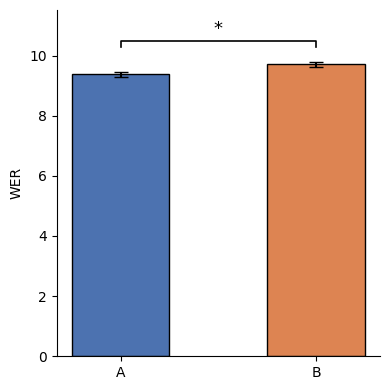

(np.float64(-4.585478527375399), np.float64(0.001317488396748739))

In [5]:
baseline_results = np.load("saved_data/baseline_5_gram_results.npy")
main_results = np.load("saved_data/main_results.npy")
paired_t_test(main_results, baseline_results)

In [ ]:
baseline_results_transformer = np.load("/home/ebrahim/brainaudio/figure_data/b2t_24_results/saved_data/transformer_unidirectional_7.5_test_5_gram.npy")
main_results_transformer = np.load("/home/ebrahim/brainaudio/figure_data/b2t_24_results/saved_data/transformer_unidirectional_7.5_test.npy")
paired_t_test(main_results_transformer, baseline_results_transformer)

In [6]:
one_sample_t_test(baseline_ref, main_results)

--- Results ---
Mean across seeds: 9.3732 (vs Baseline: 9.76)
T-statistic:    -4.93751
P-value:        0.00080

Conclusion: The difference is statistically significant (Reject H0).
Your model is significantly better than baseline.


In [ ]:
baseline_results

### Abalation #1: Calling LLM only once at the end of decoding

In [ ]:
val_scores = np.load("saved_data/val_scores.npy")
print(np.mean(val_scores), stats.sem(val_scores))

In [ ]:
no_delayed_fusion_variants = np.load("saved_data/no_delayed_fusion_ablation.npy")*100
t, p = paired_t_test(no_delayed_fusion_variants, val_scores) 

### Abalation #2: No LLM Fine-tuning

In [ ]:
no_finetuning_variants = np.load("/saved_data/no_finetuning_ablation.npy")*100
t, p = paired_t_test(no_finetuning_variants, val_scores) 

### Abalation #3: No LLM Fine-tuning

In [ ]:
no_phoneme_variants = np.load("saved_data/no_variants_ablation.npy")*100
t, p =paired_t_test(no_phoneme_variants, val_scores)


In [ ]:
unidirectional = np.load('saved_data/transformer_unidirectional.npy')
demichunked_10 = np.load('saved_data/transformer_demichunked_10.npy')
demichunked_1 = np.load('saved_data/transformer_demichunked_1.npy')

t,p = paired_t_test(unidirectional, demichunked_1)


In [ ]:
t,p = paired_t_test(demichunked_1, demichunked_10)

In [ ]:
unidirectional = np.load('saved_data/transformer_unidirectional.npy')
print(np.mean(unidirectional), np.std(unidirectional))

In [ ]:
unidirectional_test = np.load('saved_data/transformer_unidirectional_7.5_test.npy')
print(np.mean(unidirectional_test), np.std(unidirectional_test))

In [ ]:
tuned = np.array([11.19, 11.33, 11.22, 11.69, 11.31, 11.33, 12.37, 11.77, 12.33, 11.53])
bsl = np.array([11.46, 11.60, 11.11, 11.97, 11.40, 11.99, 12.55, 11.84, 12.28, 11.68])


t,p = paired_t_test(tuned, bsl)

In [ ]:
bsl = np.load('saved_data/transformer_unidirectional_20_test.npy')
tuned = np.load('saved_data/transformer_unidirectional_20_test_tuned.npy')

t,p = paired_t_test(tuned, bsl)

--- Paired T-Test Results ---
Mean A: 5.0599, SEM 0.0446
Mean B: 5.0095, SEM 0.0335
Mean difference (A - B): 0.0504
T-statistic:    1.13918
P-value:        0.28404

Conclusion: The difference is NOT statistically significant (Fail to reject H0).


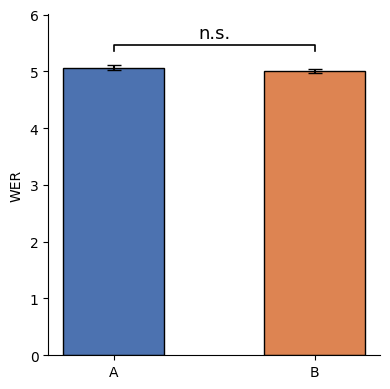

--- Results ---
Mean across seeds: 5.0599 (vs Baseline: 5.1)
T-statistic:    -0.89928
P-value:        0.39193

Conclusion: The difference is NOT statistically significant (Fail to reject H0).
--- Results ---
Mean across seeds: 5.0095 (vs Baseline: 5.1)
T-statistic:    -2.70479
P-value:        0.02420

Conclusion: The difference is statistically significant (Reject H0).
Your model is significantly better than baseline.


In [7]:
uni = np.load('saved_data/b2t_24_uni_generative.npy')
bi = np.load('saved_data/b2t_24_bi_generative.npy')

t,p = paired_t_test(uni, bi)
one_sample_t_test(5.1, uni)
one_sample_t_test(5.1, bi)

--- Paired T-Test Results ---
Mean A: 2.4602, SEM 0.0497
Mean B: 2.5450, SEM nan
Mean difference (A - B): -0.0848
T-statistic:    -1.70486
P-value:        0.12241

Conclusion: The difference is NOT statistically significant (Fail to reject H0).


/home/ebrahim/brainaudio/figure_data/utils.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem_b = stats.sem(values_b)


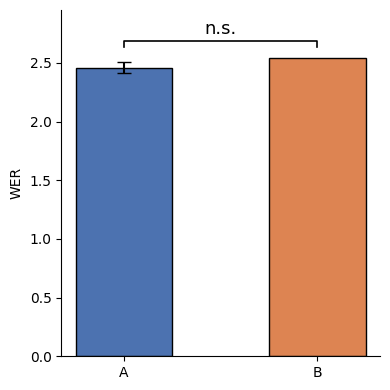

In [9]:
b2t25_uni_3b_public = np.load('../generative_results/b2t_25_3b_uni_generative_public.npy')
b2t25_uni_8b_public = np.load('../generative_results/b2t_25_8b_uni_generative_public.npy')

t,p = paired_t_test(b2t25_uni_3b_public, b2t25_uni_8b_public)

--- Paired T-Test Results ---
Mean A: 2.8951, SEM 0.0419
Mean B: 2.9340, SEM nan
Mean difference (A - B): -0.0389
T-statistic:    -0.92945
P-value:        0.37691

Conclusion: The difference is NOT statistically significant (Fail to reject H0).


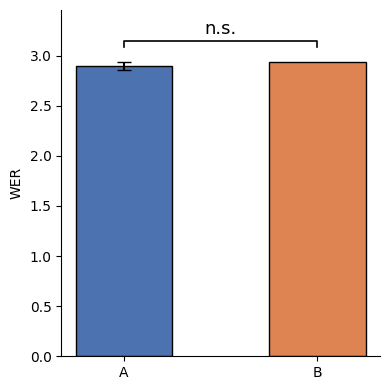

In [10]:
b2t25_uni_3b_private = np.load('../generative_results/b2t_25_3b_uni_generative_private.npy')
b2t25_uni_8b_private = np.load('../generative_results/b2t_25_8b_uni_generative_private.npy')

t,p = paired_t_test(b2t25_uni_3b_private, b2t25_uni_8b_private)

--- Paired T-Test Results ---
Mean A: 4.9866, SEM 0.0363
Mean B: 5.0095, SEM 0.0335
Mean difference (A - B): -0.0229
T-statistic:    -0.57203
P-value:        0.58131

Conclusion: The difference is NOT statistically significant (Fail to reject H0).


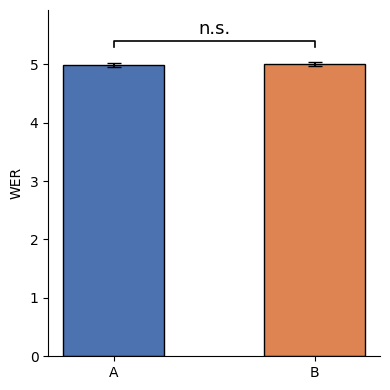

In [ ]:
b2t24_bi_3b = np.load('../generative_results/b2t_24_3b_bi_generative.npy')
b2t24_bi_8b = np.load('../generative_results/b2t_24_8b_bi_generative.npy')

t,p = paired_t_test(b2t24_bi_3b, b2t24_bi_8b)

--- Paired T-Test Results ---
Mean A: 5.4873, SEM 0.0368
Mean B: 5.0599, SEM 0.0446
Mean difference (A - B): 0.4274
T-statistic:    11.49586
P-value:        0.00000

Conclusion: The difference is statistically significant (Reject H0).
B is significantly better than A.


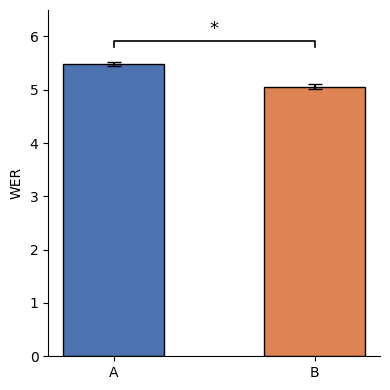

In [12]:
b2t24_uni_3b = np.load('../generative_results/b2t_24_3b_uni_generative.npy')
b2t24_uni_8b = np.load('../generative_results/b2t_24_8b_uni_generative.npy')

t,p = paired_t_test(b2t24_uni_3b, b2t24_uni_8b)

In [2]:
b2t25_bi_8b_public = np.load('../generative_results/b2t_25_8b_bi_generative_public.npy')
b2t25_bi_8b_private = np.load('../generative_results/b2t_25_8b_bi_generative_private.npy')

one_sample_t_test(2.21, b2t25_bi_8b_public)
one_sample_t_test(2.21, b2t25_bi_8b_private)

--- Results ---
Mean across seeds: 2.0843 (vs Baseline: 2.21)
T-statistic:    -3.21791
P-value:        0.01052

Conclusion: The difference is statistically significant (Reject H0).
Your model is significantly better than baseline.
--- Results ---
Mean across seeds: 2.3647 (vs Baseline: 2.21)
T-statistic:    8.62525
P-value:        0.00001

Conclusion: The difference is statistically significant (Reject H0).
Your model is significantly worse than baseline.


In [9]:
import csv                                               
from collections import defaultdict                         
                                                    
b2t_25_comparison = "/home/lionelhu/brainaudio/results/pretrained_RNN_pretrained_rnn_02_04_1843_1428701_comparison.csv"
                                                            
length_dict = defaultdict(list)                             
                                                            
with open(b2t_25_comparison, 'r', encoding='utf-8') as f:   
    all_lines = f.readlines()                               

# Find where the actual CSV starts (the header line)
start_idx = next(i for i, line in enumerate(all_lines) if
line.startswith('id,'))
csv_lines = all_lines[start_idx:]

reader = csv.DictReader(csv_lines)
counter = 0
for row in reader:
    counter += 1
    trial_idx = int(row['id'])
    category = row['category']
    ground_truth = row['ground_truth'].strip()
    sent_len = len(ground_truth.split())
    if category != "SAME":
        length_dict[sent_len].append((trial_idx, category))

length_dict = dict(sorted(length_dict.items()))
print(counter)

312


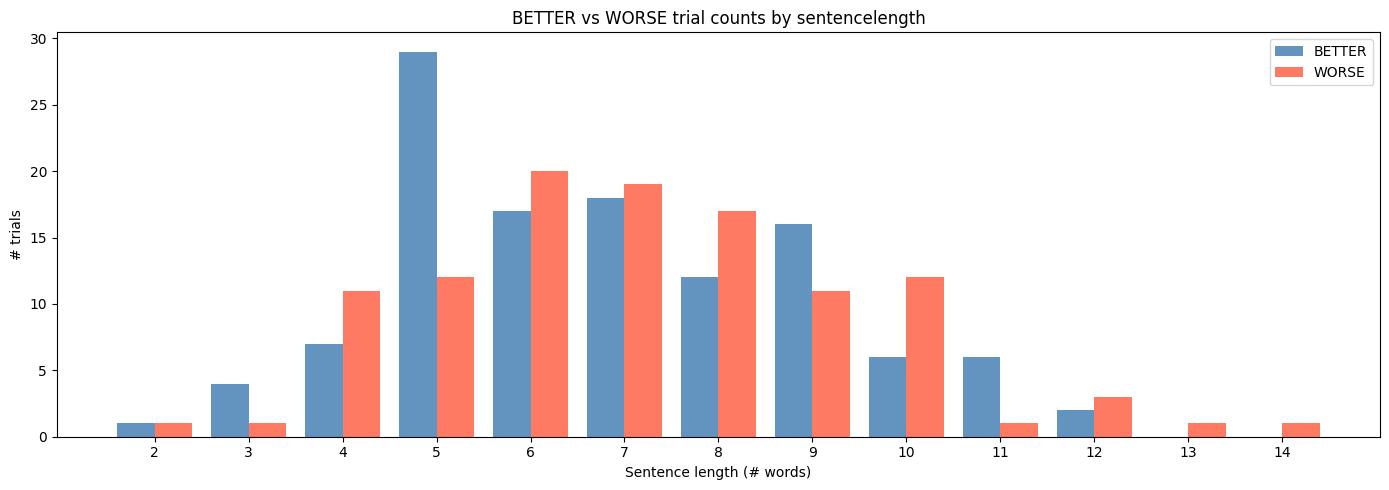

In [ ]:

import matplotlib.pyplot as plt                             
import numpy as np                                          
                                                            
# Aggregate counts per sentence length                      
lengths = sorted(length_dict.keys())                        
better_counts = [sum(1 for _, cat in length_dict[l] if cat  
== "BETTER") for l in lengths]                              
worse_counts  = [sum(1 for _, cat in length_dict[l] if cat  
== "WORSE")  for l in lengths]                              

x = np.arange(len(lengths))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, better_counts, width, label="BETTER",
color="steelblue", alpha=0.85)
ax.bar(x + width/2, worse_counts,  width, label="WORSE",
color="tomato",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(lengths)
ax.set_xlabel("Sentence length (# words)")
ax.set_ylabel("# trials")
ax.set_title("BETTER vs WORSE trial counts by sentence length B2T' 25")
ax.legend()
plt.tight_layout()
plt.show()